In [1]:
import sys
import os

sys.path.append("..")
sys.path.append("../..")
sys.path.append("../../..")

In [2]:
os.makedirs("./logs/ctr_only/", exist_ok=True)
os.makedirs("./figs/env/", exist_ok=True)
os.makedirs("./figs/exp/ctr_only/", exist_ok=True)

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from experiment.utils.utils import logit

from typing import Literal

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [5]:
from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra


GlobalHydra.instance().clear()
initialize(version_base=None, config_path="../../config")

config = compose(config_name="config")

# Environment Sampling

In [6]:
NUM_AUCTIONS = 500

In [7]:
def price2bin(price):
    """
    price = 1.2 ** bin
    """
    if price <= 0:
        return 0
    return np.round(np.log(price) / np.log(1.2))

def bin2price(bin_):
    return np.power(1.2, bin_)

In [8]:
from datasets import load_dataset, load_from_disk

if not os.path.exists("../../data/BAT/vcg_campaigns") or not os.path.exists("../../data/BAT/vcg_stats"):
    vcg_campaigns = load_dataset("AvitoTech/BAT", "vcg_campaigns")
    vcg_stats = load_dataset("AvitoTech/BAT", "vcg_stats")

    vcg_campaigns.save_to_disk("../../data/BAT/vcg_campaigns")
    vcg_stats.save_to_disk("../../data/BAT/vcg_stats")

/Users/iazhigalsky/work/denoise-bid-uai26/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
VCG_CAMPAIGNS = load_from_disk("../../data/BAT/vcg_campaigns")
VCG_STATS = load_from_disk("../../data/BAT/vcg_stats")

In [10]:
VCG_STATS_SUBSAMPLE_DF = pd.DataFrame(VCG_STATS["train"][:10_000_000])
VCG_STATS_SUBSAMPLE_DF = VCG_STATS_SUBSAMPLE_DF[VCG_STATS_SUBSAMPLE_DF["CTRPredicts"] >= 1e-9].reset_index()
VCG_CAMPAIGNS_DF = pd.DataFrame(VCG_CAMPAIGNS["train"])

unique_campaign_ids = VCG_STATS_SUBSAMPLE_DF["campaign_id"].unique()

VCG_CAMPAIGNS_SUBSAMPLE_DF = VCG_CAMPAIGNS_DF[
    VCG_CAMPAIGNS_DF["campaign_id"].isin(unique_campaign_ids)
].reset_index()

In [11]:
mask = VCG_STATS_SUBSAMPLE_DF.groupby("campaign_id")["AuctionCount"].transform("count") >= NUM_AUCTIONS
VCG_STATS_SUBSAMPLE_DF_FILTERED = VCG_STATS_SUBSAMPLE_DF[mask].copy().reset_index(drop=True)
CAMPAIGN_IDS = VCG_STATS_SUBSAMPLE_DF_FILTERED["campaign_id"].unique()

In [12]:
CAMPAIGN_IDS.shape

(334,)

In [13]:
def sample_campaign(
    seed,
    campaign_id,
    sigma_ctr = 0.0,
    sigma_cvr = 0.0,
    vcg_stats_df = VCG_STATS_SUBSAMPLE_DF_FILTERED,
):
    rng = np.random.default_rng(seed)
    campaign = vcg_stats_df[vcg_stats_df["campaign_id"] == campaign_id]

    weights = np.array(campaign["AuctionCount"], dtype=np.float64)
    weights /= weights.sum()

    idxs = rng.choice(len(campaign), size=len(campaign), p=weights, replace=True)
    logs = vcg_stats_df.iloc[idxs]

    place_count = logs["AuctionCount"]
    ctr_clean = np.array(logs["CTRPredicts"] / place_count)
    cvr_clean = np.array(logs["CRPredicts"] / place_count)
    wp = np.array(bin2price(logs["contact_price_bin"]) / place_count)

    ctr_clean_logit = logit(ctr_clean)
    cvr_clean_logit = logit(cvr_clean)
    ctr_noised_logit = ctr_clean_logit + rng.normal(0, sigma_ctr, len(campaign))
    cvr_noised_logit = cvr_clean_logit + rng.normal(0, sigma_cvr, len(campaign))

    return ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp

## DISTRIBUTIONS hist

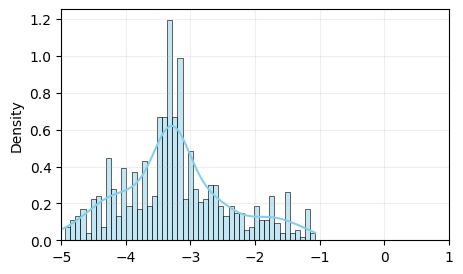

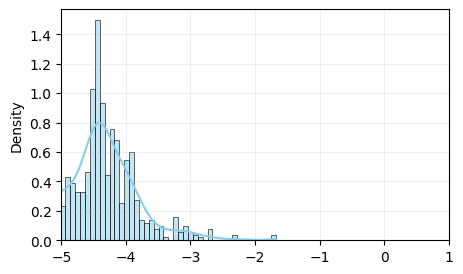

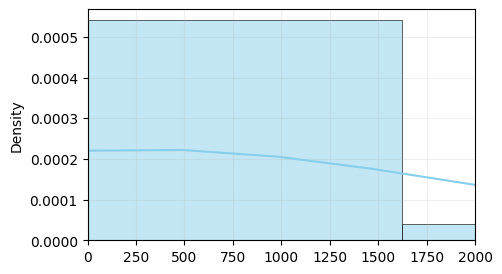

In [14]:
def visualize_samples(samples, figname, clip=[0, 1], logit_space=False):
    plt.figure(figsize=(5, 3))

    if logit_space:
        samples = logit(samples)
    sns.histplot(samples, bins=60, kde=True, stat="density", color='skyblue')

    plt.xlim(clip)

    plt.savefig(figname, format="pdf", bbox_inches="tight")
    plt.grid(alpha=0.2)
    plt.show()

ctr_data, _, cvr_data, _, wp = sample_campaign(
    seed = 1,
    campaign_id = CAMPAIGN_IDS[0],
    sigma_ctr=1e-1,
    sigma_cvr=1e-1,
)

visualize_samples(ctr_data, f"figs/env/ctr_{len(ctr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(cvr_data, f"figs/env/cvr_{len(cvr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(wp, f"figs/env/wp_{len(wp)}samples.pdf", clip=[0, 2_000])

In [ ]:
from experiment.non_robust_bid.offline_bidder import non_robust_bid
from experiment.denoise_bid.ctr_only.offline_bidder import denoise_bid as ctr_only_denoise_bid

from experiment.non_robust_bid.lp import solve_dual as non_robust_dual
from experiment.non_robust_bid.bid import bids as non_robust_bids

from experiment.utils.utils import sigmoid

## Metrics calculation on clean environment

In [16]:
def simulate_offline_metrics(config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc):
    is_win = bids >= wp
    total_conversions = float(np.sum(ctr_clean * cvr_clean * is_win))

    total_avg_cpc = wp.sum() / ctr_clean.sum()

    p, q = non_robust_dual(config.algorithms.non_robust_bid, ctr_clean, cvr_clean, wp, budget, target_cpc)
    opt_bids = non_robust_bids(ctr_clean, cvr_clean, p, q, target_cpc)
    opt_value = ((opt_bids > wp) * ctr_clean * cvr_clean).sum()
    value_ratio = total_conversions / opt_value

    total_cost = float(np.sum(wp * is_win))
    total_clicks = float(np.sum(ctr_clean * is_win))
    avg_cpc = total_cost / total_clicks if total_clicks > 0 else 0.0

    avg_cpc_ratio = avg_cpc / total_avg_cpc

    return {
        "total_conversions": value_ratio,
        "avg_cpc": avg_cpc_ratio,
    }

## Experiment function

In [ ]:
def run_single_experiment(
    config,
    campaign_id: int,
    sigma_ctr: float,
    budget_proportion: float,
    target_cpc_proportion: float,
    bidder_mode: Literal["non-robust", "denoise"] = "non-robust",
    n_components=1,
    risk_coeff=None,
):
    sigma_cvr = 0.0
    ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp = sample_campaign(config.common.seed, campaign_id, sigma_ctr, sigma_cvr)

    ctr_clean = sigmoid(ctr_clean_logit)
    cvr_clean = sigmoid(cvr_clean_logit)
    ctr_noised = sigmoid(ctr_noised_logit)
    cvr_noised = sigmoid(cvr_noised_logit)

    budget = budget_proportion * wp.sum()
    target_cpc = target_cpc_proportion * wp.sum() / ctr_clean.sum()

    if bidder_mode == "non-robust":
        bids = non_robust_bid(config.algorithms.non_robust_bid, ctr_noised_logit, cvr_noised_logit, wp, budget, target_cpc)
        metrics = simulate_offline_metrics(
            config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc
        )

    elif bidder_mode == "denoise":
        bids = ctr_only_denoise_bid(
            config.algorithms.denoise_bid.ctr_only,
            ctr_noised_logit,
            np.ones_like(ctr_noised_logit) * sigma_ctr,
            cvr_noised_logit,
            np.ones_like(cvr_noised_logit) * sigma_cvr,
            wp,
            budget,
            target_cpc,
            n_components=n_components,
        )

        metrics = simulate_offline_metrics(
            config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    return {
        "sigma": sigma_ctr,
        "seed": config.common.seed,
        "metrics": metrics,
    }

### Experiment aggregating function

In [18]:
def aggregate_results(raw_path: str, summary_path: str):
    df = pd.read_csv(raw_path)
    grouped = (
        df.groupby("sigma")
        .agg(
            total_conversions_mean=("conversions", "mean"),
            total_conversions_std=("conversions", "std"),
            avg_cpc_mean=("cpc", "mean"),
            avg_cpc_std=("cpc", "std"),
        )
        .reset_index()
    )
    grouped.to_csv(summary_path, index=False)
    return summary_path

# ALL ALGORITHMS COMPARISON

In [19]:
SIGMAS = np.logspace(-2, 1, 10)
NUM_SEEDS = len(CAMPAIGN_IDS)

CAMPAIGN_IDS_SUBSAMPLE = CAMPAIGN_IDS[:NUM_SEEDS]
BUDGET_PROPORTION = 0.2
TARGET_CPC_PROPORTION = 0.2

In [20]:
rows_non_robust = []
rows_normal = []
rows_2_comp = []
rows_3_comp = []
rows_4_comp = []


for sigma in tqdm(SIGMAS):
    for camp_id in CAMPAIGN_IDS_SUBSAMPLE:
        try:
            exp_res_nr = run_single_experiment(config, camp_id, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="non-robust")
            exp_res_norm = run_single_experiment(config, camp_id, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=1)
            exp_res_gm2 = run_single_experiment(config, camp_id, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=2)
            exp_res_gm3 = run_single_experiment(config, camp_id, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=3)
            exp_res_gm4 = run_single_experiment(config, camp_id, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=4)

            rows_normal.append(
                {
                    "sigma": sigma,
                    "SEED": config.common.seed,
                    "conversions": exp_res_norm["metrics"]["total_conversions"],
                    "cpc": exp_res_norm["metrics"]["avg_cpc"],
                }
            )

            rows_2_comp.append(
                {
                    "sigma": sigma,
                    "SEED": config.common.seed,
                    "conversions": exp_res_gm2["metrics"]["total_conversions"],
                    "cpc": exp_res_gm2["metrics"]["avg_cpc"],
                }
            )

            rows_non_robust.append(
                {
                    "sigma": sigma,
                    "SEED": config.common.seed,
                    "conversions": exp_res_nr["metrics"]["total_conversions"],
                    "cpc": exp_res_nr["metrics"]["avg_cpc"],
                }
            )

            rows_3_comp.append(
                {
                    "sigma": sigma,
                    "SEED": config.common.seed,
                    "conversions": exp_res_gm3["metrics"]["total_conversions"],
                    "cpc": exp_res_gm3["metrics"]["avg_cpc"],
                }
            )

            rows_4_comp.append(
                {
                    "sigma": sigma,
                    "SEED": config.common.seed,
                    "conversions": exp_res_gm4["metrics"]["total_conversions"],
                    "cpc": exp_res_gm4["metrics"]["avg_cpc"],
                }
            )
        except Exception as e:
            print(f"Error in seed {config.common.seed}, sigma {sigma}: {e}")
            continue


df_non_robust = pd.DataFrame(rows_non_robust)
df_normal = pd.DataFrame(rows_normal)
df_2_comp = pd.DataFrame(rows_2_comp)
df_3_comp = pd.DataFrame(rows_3_comp)
df_4_comp = pd.DataFrame(rows_4_comp)

non_robust_all_path = f"logs/ctr_only/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
normal_all_path = f"logs/ctr_only/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_2_comp_all_path = f"logs/ctr_only/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_3_comp_all_path = f"logs/ctr_only/gm3_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_4_comp_all_path = f"logs/ctr_only/gm4_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"


df_non_robust.to_csv(non_robust_all_path, index=False)
df_normal.to_csv(normal_all_path, index=False)
df_2_comp.to_csv(gm_2_comp_all_path, index=False)
df_3_comp.to_csv(gm_3_comp_all_path, index=False)
df_4_comp.to_csv(gm_4_comp_all_path, index=False)

100%|██████████| 10/10 [13:16:48<00:00, 4780.82s/it] 


In [21]:
non_robust_summary_path = f"logs/ctr_only/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
normal_summary_path = f"logs/ctr_only/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_2_comp_summary_path = f"logs/ctr_only/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_3_comp_summary_path = f"logs/ctr_only/gm3_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_4_comp_summary_path = f"logs/ctr_only/gm4_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"

aggregate_results(non_robust_all_path, non_robust_summary_path)
aggregate_results(normal_all_path, normal_summary_path)
aggregate_results(gm_2_comp_all_path, gm_2_comp_summary_path)
aggregate_results(gm_3_comp_all_path, gm_3_comp_summary_path)
aggregate_results(gm_4_comp_all_path, gm_4_comp_summary_path)

'logs/ctr_only/gm4_c0.2_b0.2_summary.csv'

### *FIGURE*

In [25]:
df_list_names = [
    f"logs/ctr_only/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/gm3_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/gm4_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
]

exp_num = len(df_list_names)

name_fig = f"figs/exp/ctr_only/diff_gaussian_num_b{BUDGET_PROPORTION}_c{TARGET_CPC_PROPORTION}.pdf"
c_arr = ["NonRobustBid", "DenoiseBid (normal prior)", "DenoiseBid (2-comp prior)", "DenoiseBid (3-comp prior)", "DenoiseBid (4-comp prior)"]

In [39]:
metrics = [
    {
        "name": "total_conversions",
        "title": "",
        "ylabel": "${R}\\,/\\,{R*}$",
    },
    {
        "name": "avg_cpc",
        "title": "",
        "ylabel": "${\\overline{CPC}}\\,/\\,{\\overline{CPC}_\\text{campaign}}$",
    },
]

dfs = []
for name in df_list_names:
    dfs.append(pd.read_csv(name))

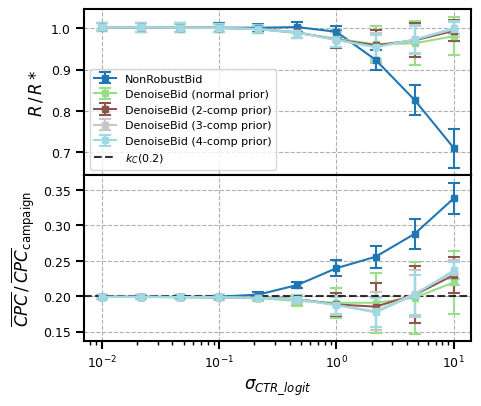

In [40]:
colors = plt.cm.tab20(np.linspace(0, 1, len(dfs)))
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(5, 4),
    gridspec_kw=dict(hspace=0)
)

for idx, (ax, metric) in enumerate(zip(axes, metrics)):
    ax.set_xscale("log")
    ax.grid(True, linestyle="--")
    ax.set_ylabel(metric["ylabel"], fontsize=12)

    ax.tick_params(axis="both", which="major", labelsize=9, width=1.5, length=6)
    ax.tick_params(axis="both", which="minor", labelsize=9, width=1, length=3)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    for i, df in enumerate(dfs):
        ax.errorbar(
            df["sigma"],
            df[f"{metric['name']}_mean"],
            yerr=df[f"{metric['name']}_std"],
            label=f"{c_arr[i]}",
            fmt="s-",
            capsize=4,
            capthick=1.5,
            elinewidth=1.5,
            markersize=4,
            color=colors[i],
        )

axes[0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

axes[1].set_xlabel("$\\sigma_{CTR\\_logit}$", fontsize=12)
axes[1].axhline(TARGET_CPC_PROPORTION, c="k", alpha=0.8, label="$k_C (0.2)$", linestyle="dashed", linewidth=1.5)

# axes[0].legend(frameon=True, fontsize=8, loc=2)
handles, labels = axes[1].get_legend_handles_labels()
target_label = '$k_C (0.2)$'
if target_label in labels:
    idx = labels.index(target_label)

    h = handles.pop(idx)
    l = labels.pop(idx)

    handles.append(h)
    labels.append(l)

axes[0].legend(handles, labels, frameon=True, fontsize=8, loc=3)

plt.subplots_adjust(top=0.88, bottom=0.05)
plt.savefig(name_fig, format="pdf", bbox_inches="tight")
plt.show()